In [153]:
# Task 1 dataset (from the assignment PDF)
transactions = {
    0:["Elixir", "Shield"],
    1:["Gem", "Shield"],
    2:["Elixir", "Sword"],
    3:["Elixir", "Wand", "Shield"],
    4:["Elixir", "Sword"],
    5:["Wand", "Shield"],
    6:["Elixir", "Wand", "Shield", "Sword"],
    7: ["Elixir", "Giant Wand"]

}


transactions

{0: ['Elixir', 'Shield'],
 1: ['Gem', 'Shield'],
 2: ['Elixir', 'Sword'],
 3: ['Elixir', 'Wand', 'Shield'],
 4: ['Elixir', 'Sword'],
 5: ['Wand', 'Shield'],
 6: ['Elixir', 'Wand', 'Shield', 'Sword'],
 7: ['Elixir', 'Giant Wand']}

In [154]:
# =========================================================
# Utilities
# =========================================================

def preprocess_transactions(transactions: dict) -> dict:
    """Ensure each transaction is a set."""
    return {
        k: (v if isinstance(v, set) else set(v))
        for k, v in transactions.items()
    }


def sample_transactions(
    transactions: dict,
    n: int,
    seed: int = 42,
    random_sample: bool = True
) -> dict:
    """
    Return a subset of transactions of size n.
    """
    if n >= len(transactions):
        return transactions

    rnd = random.Random(seed)

    if random_sample:
        keys = rnd.sample(list(transactions.keys()), n)
        return {k: transactions[k] for k in keys}

    return dict(islice(transactions.items(), n))


def filter_items_by_min_count(transactions: dict, min_count: int = 20) -> dict:
    """
    Remove very rare items before Apriori.
    This is one of the strongest runtime reductions.
    """
    item_counts = {}
    for items in transactions.values():
        for item in items:
            item_counts[item] = item_counts.get(item, 0) + 1

    keep = {item for item, cnt in item_counts.items() if cnt >= min_count}

    filtered = {}
    for user, items in transactions.items():
        kept_items = set(items) & keep
        if kept_items:
            filtered[user] = kept_items

    return filtered


In [155]:
from itertools import combinations

def compute_support(itemset, transactions, sup_cache=None):

    if sup_cache is None:
        sup_cache = {}

    key = itemset if isinstance(itemset, frozenset) else frozenset(itemset)

    # lookup first
    if key in sup_cache:
        return sup_cache[key]

    # compute if not cached
    count = 0
    for t in transactions.values():
        if key.issubset(t if isinstance(t, set) else set(t)):
            count += 1

    val = count / len(transactions) if transactions else 0.0
    sup_cache[key] = val
    return val

In [156]:
def generate_C1(transactions):
    C1 = set()
    for transaction,itemset in transactions.items():

        for item in itemset:
            C1.add(frozenset([item]))
    return list(C1)

def filter_frequent(Ck, transactions, Smin, sup_cache=None):
    if sup_cache is None:
        sup_cache = {}

    Fk = []
    for c in Ck:
        if compute_support(c, transactions, sup_cache) >= Smin:
            Fk.append(c)
    return Fk

In [157]:
from itertools import combinations

def _has_infrequent_subset(candidate, prev_frequents_set, subset_size):
    """
    Return True if candidate has at least one subset of size subset_size
    that is not in the previous frequent itemsets.
    """
    for subset in combinations(candidate, subset_size):
        if frozenset(subset) not in prev_frequents_set:
            return True
    return False

In [158]:
def apriori(
    transactions,
    Smin,
    sup_cache=None,
    max_k=3,
    max_itemsets=5000
):
    """
    Apriori with:
      - max_k cap
      - duplicate-candidate removal
      - subset pruning
      - itemset cap to avoid explosion

    Returns:
      list of frequent itemsets
    """
    if sup_cache is None:
        sup_cache = {}

    transactions = preprocess_transactions(transactions)

    C1 = generate_C1(transactions)
    F1 = filter_frequent(C1, transactions, Smin, sup_cache)

    F = list(F1)
    Fk = F1
    k = 2

    while Fk and k <= max_k:
        prev_frequents_set = set(Fk)
        Ck = set()

        # join step
        for i in range(len(Fk)):
            for j in range(i + 1, len(Fk)):
                L1 = sorted(Fk[i])
                L2 = sorted(Fk[j])

                if L1[:k - 2] == L2[:k - 2]:
                    candidate = frozenset(Fk[i] | Fk[j])

                    if len(candidate) != k:
                        continue

                    # prune step
                    if _has_infrequent_subset(candidate, prev_frequents_set, k - 1):
                        continue

                    Ck.add(candidate)

        if not Ck:
            break

        Fk_plus_1 = filter_frequent(Ck, transactions, Smin, sup_cache)

        if not Fk_plus_1:
            break

        F.extend(Fk_plus_1)

        if len(F) > max_itemsets:
            return F[:max_itemsets]

        Fk = Fk_plus_1
        k += 1

    return F

In [159]:
def generate_rules(
    frequent_itemsets,
    transactions,
    Cmin,
    sup_cache=None,
    max_rules=5000,
    max_k=3
):
    """
    Generate association rules with caps to avoid 2^k blow-up.
    Returns:
      rules, sup_cache
    rule format:
      (A, B, support_AB, confidence, lift)
    """
    if sup_cache is None:
        sup_cache = {}

    transactions = preprocess_transactions(transactions)
    rules = []

    for itemset in frequent_itemsets:
        itemset = itemset if isinstance(itemset, frozenset) else frozenset(itemset)

        if len(itemset) < 2:
            continue
        if len(itemset) > max_k:
            continue

        items = list(itemset)
        sup_AB = compute_support(itemset, transactions, sup_cache)

        for i in range(1, len(items)):
            for A in combinations(items, i):
                A = frozenset(A)
                B = itemset - A

                sup_A = compute_support(A, transactions, sup_cache)
                if sup_A == 0:
                    continue

                conf = sup_AB / sup_A
                if conf < Cmin:
                    continue

                sup_B = compute_support(B, transactions, sup_cache)
                if sup_B == 0:
                    continue

                lift = conf / sup_B
                rules.append((A, B, sup_AB, conf, lift))

                if len(rules) >= max_rules:
                    return rules, sup_cache

    return rules, sup_cache


In [160]:
from itertools import combinations, islice
from abc import ABC, abstractmethod
import math
import random
import optuna


In [161]:
# =========================================================
# Optimization base
# =========================================================

class Optimization(ABC):
    def __init__(
        self,
        transactions,
        max_k=3,
        max_itemsets=5000,
        max_rules=5000,
        min_lift=1.0
    ):
        self.transactions = preprocess_transactions(transactions)
        self.max_k = int(max_k)
        self.max_itemsets = int(max_itemsets)
        self.max_rules = int(max_rules)
        self.min_lift = float(min_lift)

    def evaluate_rules(self, rules, min_lift=None):
        if min_lift is None:
            min_lift = self.min_lift

        good = [r for r in rules if r[4] > min_lift]
        if not good:
            return 0.0

        avg_lift = sum(r[4] for r in good) / len(good)
        return avg_lift * math.log1p(len(good))

    @abstractmethod
    def optimize(self):
        pass

# Bayesian Optimization

In [162]:
# =========================================================
# Bayesian optimization
# =========================================================

class BayesianOptimization(Optimization):
    def __init__(
        self,
        transactions,
        n_trials=10,
        max_k=3,
        max_itemsets=5000,
        max_rules=5000,
        min_lift=1.0,
        seed=42,
        smin_range=(0.05, 0.30),
        cmin_range=(0.30, 0.95),
    ):
        super().__init__(
            transactions,
            max_k=max_k,
            max_itemsets=max_itemsets,
            max_rules=max_rules,
            min_lift=min_lift
        )
        self.n_trials = int(n_trials)
        self.seed = int(seed)
        self.smin_range = smin_range
        self.cmin_range = cmin_range

        self.best_params = None
        self.best_score = float("-inf")
        self.best_rules = None
        self.best_itemsets = None
        self.global_sup_cache = {}

    def objective(self, trial):
        Smin = trial.suggest_float(
            "Smin",
            self.smin_range[0],
            self.smin_range[1],
            log=True
        )
        Cmin = trial.suggest_float(
            "Cmin",
            self.cmin_range[0],
            self.cmin_range[1]
        )

        sup_cache = self.global_sup_cache

        frequent_itemsets = apriori(
            self.transactions,
            Smin,
            sup_cache=sup_cache,
            max_k=self.max_k,
            max_itemsets=self.max_itemsets
        )

        if not frequent_itemsets:
            raise optuna.TrialPruned()

        if len(frequent_itemsets) > self.max_itemsets:
            raise optuna.TrialPruned()

        rules, _ = generate_rules(
            frequent_itemsets,
            self.transactions,
            Cmin,
            sup_cache=sup_cache,
            max_rules=self.max_rules,
            max_k=self.max_k
        )

        score = self.evaluate_rules(rules)

        if score > self.best_score:
            self.best_score = score
            self.best_params = {"Smin": Smin, "Cmin": Cmin}
            self.best_rules = rules
            self.best_itemsets = frequent_itemsets

        return score

    def optimize(self):
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        study.optimize(self.objective, n_trials=self.n_trials)

        return self.best_params, self.best_score, self.best_rules, self.best_itemsets, self.global_sup_cache   


# Genetic Alogrithm

In [235]:
import random
import time


# =========================================================
# Genetic optimization
# =========================================================

class GeneticOptimization(Optimization):
    def __init__(
        self,
        transactions,
        pop_size=20,
        generations=10,
        elite_frac=0.15,
        crossover_prob=0.9,
        mutation_prob=0.3,
        smin_bounds=(0.05, 0.30),
        cmin_bounds=(0.30, 0.95),
        mutation_sigma_smin=0.02,
        mutation_sigma_cmin=0.05,
        seed=42,
        max_k=3,
        max_itemsets=5000,
        max_rules=5000,
        min_lift=1.0,
        patience=5,
        generation_time_limit=60.0,
    ):
        super().__init__(
            transactions,
            max_k=max_k,
            max_itemsets=max_itemsets,
            max_rules=max_rules,
            min_lift=min_lift
        )

        self.pop_size = int(pop_size)
        self.generations = int(generations)
        self.elite_frac = float(elite_frac)
        self.crossover_prob = float(crossover_prob)
        self.mutation_prob = float(mutation_prob)
        self.smin_bounds = smin_bounds
        self.cmin_bounds = cmin_bounds
        self.mutation_sigma_smin = float(mutation_sigma_smin)
        self.mutation_sigma_cmin = float(mutation_sigma_cmin)
        self.patience = int(patience)
        self.generation_time_limit = float(generation_time_limit)

        self.global_sup_cache = {}

        random.seed(int(seed))

    @staticmethod
    def _clip(x, lo, hi):
        return max(lo, min(hi, x))

    @staticmethod
    def _tournament_select(population, fitnesses, k=3):
        k = min(k, len(population))
        idxs = random.sample(range(len(population)), k)
        best = max(idxs, key=lambda i: fitnesses[i])
        return population[best]

    def _evaluate_candidate(self, Smin, Cmin):
        sup_cache = self.global_sup_cache

        itemsets = apriori(
            self.transactions,
            Smin,
            sup_cache=sup_cache,
            max_k=self.max_k,
            max_itemsets=self.max_itemsets
        )

        if not itemsets:
            return 0.0, None, None

        if len(itemsets) > self.max_itemsets:
            return 0.0, None, None

        rules, _ = generate_rules(
            itemsets,
            self.transactions,
            Cmin,
            sup_cache=sup_cache,
            max_rules=self.max_rules,
            max_k=self.max_k
        )

        score = self.evaluate_rules(rules)
        return score, rules, itemsets

    def optimize(self):
        best_params = None
        best_score = float("-inf")
        best_rules = None
        best_itemsets = None

        no_improve_count = 0

        population = [
            (random.uniform(*self.smin_bounds), random.uniform(*self.cmin_bounds))
            for _ in range(self.pop_size)
        ]

        fitnesses = []
        for s, c in population:
            score, _, _ = self._evaluate_candidate(s, c)
            fitnesses.append(score)

        for gen in range(self.generations):
            gen_start_time = time.time()

            gen_best_idx = max(range(len(population)), key=lambda i: fitnesses[i])
            s_best, c_best = population[gen_best_idx]
            score, rules, itemsets = self._evaluate_candidate(s_best, c_best)

            improved = False
            if itemsets is not None and score > best_score:
                best_score = score
                best_params = {"Smin": s_best, "Cmin": c_best}
                best_rules = rules
                best_itemsets = itemsets
                improved = True

            if improved:
                no_improve_count = 0
            else:
                no_improve_count += 1

            print(
                f"Gen {gen + 1:02d} | "
                f"best fitness={max(fitnesses):.6f} | "
                f"global best={best_score:.6f} | "
                f"no_improve={no_improve_count}/{self.patience}"
            )

            if no_improve_count >= self.patience:
                print(f"Stopping early: no improvement for {self.patience} generations.")
                break

            elite_count = max(1, int(self.elite_frac * self.pop_size))
            ranked = sorted(zip(population, fitnesses), key=lambda x: x[1], reverse=True)
            elites = [ind for ind, _ in ranked[:elite_count]]

            new_pop = elites[:]

            while len(new_pop) < self.pop_size:
                if time.time() - gen_start_time > self.generation_time_limit:
                    print(
                        f"Stopping generation {gen + 1:02d} early: "
                        f"time limit of {self.generation_time_limit:.1f}s exceeded."
                    )
                    break

                p1 = self._tournament_select(population, fitnesses, k=3)
                p2 = self._tournament_select(population, fitnesses, k=3)

                if random.random() < self.crossover_prob:
                    alpha = random.random()
                    child_s = alpha * p1[0] + (1 - alpha) * p2[0]
                    child_c = alpha * p1[1] + (1 - alpha) * p2[1]
                else:
                    child_s, child_c = p1

                if random.random() < self.mutation_prob:
                    child_s += random.gauss(0, self.mutation_sigma_smin)
                    child_c += random.gauss(0, self.mutation_sigma_cmin)

                child_s = self._clip(child_s, *self.smin_bounds)
                child_c = self._clip(child_c, *self.cmin_bounds)

                new_pop.append((child_s, child_c))

            while len(new_pop) < self.pop_size:
                new_pop.append(
                    (random.uniform(*self.smin_bounds), random.uniform(*self.cmin_bounds))
                )

            population = new_pop

            fitnesses = []
            eval_stopped_by_time = False

            for s, c in population:
                if time.time() - gen_start_time > self.generation_time_limit:
                    print(
                        f"Stopping evaluation in generation {gen + 1:02d}: "
                        f"time limit of {self.generation_time_limit:.1f}s exceeded."
                    )
                    eval_stopped_by_time = True
                    break

                score, _, _ = self._evaluate_candidate(s, c)
                fitnesses.append(score)

            if eval_stopped_by_time:
                while len(fitnesses) < len(population):
                    fitnesses.append(float("-inf"))

        return best_params, best_score, best_rules, best_itemsets, self.global_sup_cache

# Optimization Factory

In [164]:
class OptimizationFactory:
    @staticmethod
    def create(method, transactions, **kwargs):
        method = method.lower()
        if method == "bayesian":
            return BayesianOptimization(transactions, **kwargs)
        elif method == "genetic":
            return GeneticOptimization(transactions, **kwargs)
        else:
            raise ValueError("Unknown method")

In [165]:
# =========================================================
# One-shot evaluation
# =========================================================

def evaluate_params(
    transactions: dict,
    Smin: float,
    Cmin: float,
    max_itemsets: int = 5000,
    max_rules: int = 5000,
    max_k: int = 3,
    min_lift: float = 1.0
) -> dict:
    """
    Run Apriori + rule generation once.
    """
    transactions = preprocess_transactions(transactions)
    sup_cache = {}

    itemsets = apriori(
        transactions,
        Smin,
        sup_cache=sup_cache,
        max_k=max_k,
        max_itemsets=max_itemsets
    )

    if not itemsets:
        return {
            "score": 0.0,
            "params": {"Smin": Smin, "Cmin": Cmin},
            "rules": [],
            "itemsets": []
        }

    if len(itemsets) > max_itemsets:
        return {
            "score": 0.0,
            "params": {"Smin": Smin, "Cmin": Cmin},
            "rules": [],
            "itemsets": []
        }

    rules, _ = generate_rules(
        itemsets,
        transactions,
        Cmin,
        sup_cache=sup_cache,
        max_rules=max_rules,
        max_k=max_k
    )

    good = [r for r in rules if r[4] > min_lift]
    if not good:
        score = 0.0
    else:
        avg_lift = sum(r[4] for r in good) / len(good)
        score = avg_lift * math.log1p(len(good))

    return {
        "score": score,
        "params": {"Smin": Smin, "Cmin": Cmin},
        "rules": rules,
        "itemsets": itemsets
    }


In [166]:
# =========================================================
# Optional staged random search
# =========================================================

def staged_random_search(
    transactions: dict,
    n_stage1: int = 1000,
    n_random: int = 30,
    top_k: int = 5,
    seed: int = 42,
    smin_range=(0.05, 0.30),
    cmin_range=(0.30, 0.95),
    max_itemsets_stage1: int = 1000,
    max_itemsets_full: int = 5000,
    max_rules: int = 5000,
    max_k: int = 3,
    min_lift: float = 1.0,
):
    """
    Step 1: random search on subset
    Step 2: keep top_k parameter sets
    Step 3: re-evaluate on full data
    """
    rnd = random.Random(seed)
    transactions = preprocess_transactions(transactions)

    tx_small = sample_transactions(
        transactions,
        n_stage1,
        seed=seed,
        random_sample=True
    )

    stage1_results = []
    for _ in range(n_random):
        Smin = rnd.uniform(*smin_range)
        Cmin = rnd.uniform(*cmin_range)

        result = evaluate_params(
            tx_small,
            Smin,
            Cmin,
            max_itemsets=max_itemsets_stage1,
            max_rules=max_rules,
            max_k=max_k,
            min_lift=min_lift
        )
        stage1_results.append(result)

    stage1_results.sort(key=lambda x: x["score"], reverse=True)
    top_stage1 = stage1_results[:top_k]

    full_results = []
    for cand in top_stage1:
        full_result = evaluate_params(
            transactions,
            cand["params"]["Smin"],
            cand["params"]["Cmin"],
            max_itemsets=max_itemsets_full,
            max_rules=max_rules,
            max_k=max_k,
            min_lift=min_lift
        )
        full_results.append(full_result)

    full_results.sort(key=lambda x: x["score"], reverse=True)
    best_full = full_results[0] if full_results else None

    return best_full, full_results, top_stage1

In [167]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions,
    n_trials=10,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8)
)

In [168]:


params, score, rules, itemset,sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)

[I 2026-03-09 23:29:45,239] A new study created in memory with name: no-name-b1ee9e66-bd48-4146-868e-433cc405616b
[I 2026-03-09 23:29:45,240] Trial 0 finished with value: 3.684136148790474 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 3.684136148790474.
[I 2026-03-09 23:29:45,241] Trial 1 finished with value: 4.1799174714188005 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 1 with value: 4.1799174714188005.
[I 2026-03-09 23:29:45,241] Trial 2 finished with value: 4.730386197236599 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 4.730386197236599.
[I 2026-03-09 23:29:45,242] Trial 3 finished with value: 3.684136148790474 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 4.730386197236599.
[I 2026-03-09 23:29:45,242] Trial 4 finished with value: 4.056170854603443 and parameters: {'S

Best Smin: 0.013832442448846112
Best Cmin: 0.2935967122017216
Best Score: 4.730386197236599


In [169]:
Smin=params['Smin']
Cmin=params['Cmin']

In [170]:
import matplotlib.pyplot as plt

def plot(rules):
    supports = [r[2] for r in rules]
    confidences = [r[3] for r in rules]

    plt.figure(figsize=(6,4))
    plt.scatter(confidences, supports)
    plt.xlabel("Confidence")
    plt.ylabel("Support")
    plt.title("Support vs Confidence (Task 1)")
    plt.grid(True)
    plt.show()

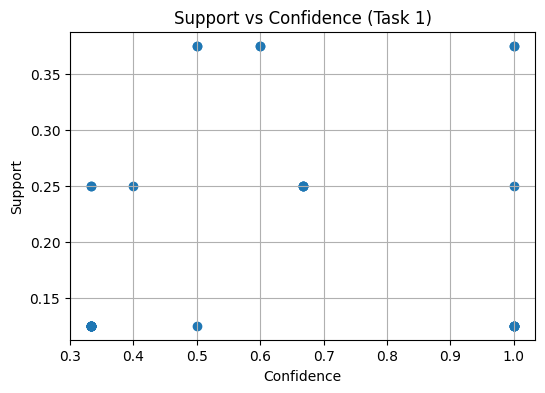

In [171]:
plot(rules)

In [172]:
import numpy as np

def heat_map(rules):
    
    supports = [r[2] for r in rules]
    confidences = [r[3] for r in rules]
    lifts = [r[4] for r in rules]

    scaled_lifts = np.clip(np.array(lifts) * 15, 20, 200)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(confidences, supports, c=lifts, s=scaled_lifts, cmap='plasma', alpha=0.7)

    cbar = plt.colorbar(scatter)
    cbar.set_label('Lift Value')

    plt.xlabel("Confidence")
    plt.ylabel("Support")
    plt.title("Support vs Confidence vs. Lift (Task 1) - Lift = Color & Size")
    plt.grid(True)
    plt.show()

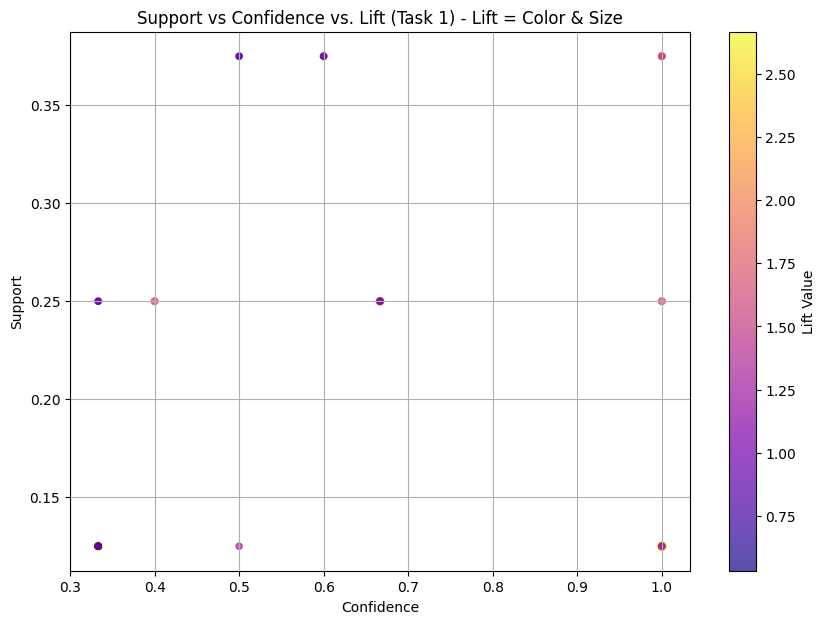

In [173]:
heat_map(rules)

# Task 2

### Task 2.1

Every transaction in our database will correspond to a unique user and it maps user to movie_id that he rated.


In [174]:
import pandas as pd

ratings=pd.read_csv("datasets/ratings.dat",sep="::",header=None,names=['UserID','MovieID','Rating','Timestamp'])
users=pd.read_csv("datasets/users.dat",sep="::",index_col=0,header=None,names=['UserID','Gender','Age','Occupation','Zip-code'])
movies= pd.read_csv(
    "datasets/movies.dat",
    sep="::",
    index_col=0,
    engine="python",
    header=None,
    names=["MovieID", "Title", "Genres"],
    encoding="latin1"
)


/var/folders/qd/qtdqglvs7tz_v0q305tw1dm00000gn/T/ipykernel_1150/671999641.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  ratings=pd.read_csv("datasets/ratings.dat",sep="::",header=None,names=['UserID','MovieID','Rating','Timestamp'])
/var/folders/qd/qtdqglvs7tz_v0q305tw1dm00000gn/T/ipykernel_1150/671999641.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  users=pd.read_csv("datasets/users.dat",sep="::",index_col=0,header=None,names=['UserID','Gender','Age','Occupation','Zip-code'])


In [175]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [176]:
users.head()

,Gender,Age,Occupation,Zip-code
UserID,,,,
1,F,1,10,48067
2,M,56,16,70072
3,M,25,15,55117
4,M,45,7,02460
5,M,25,20,55455


In [177]:
movies.head()


,Title,Genres
MovieID,,
1,Toy Story (1995),Animation|Children's|Comedy
2,Jumanji (1995),Adventure|Children's|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama
5,Father of the Bride Part II (1995),Comedy


In [178]:
from collections import defaultdict

T_plus= defaultdict(list)
T_min= defaultdict(list)

T_plus for high ratings (4 or 5)
T_min for low ratings (1 or 2)

In [179]:
for user_id, rows in ratings.groupby("UserID"):
    for movie_id, rating in zip(rows["MovieID"], rows["Rating"]):
        if rating==4 or rating==5:
            T_plus[user_id].append(str(movie_id))
        elif rating==2 or rating==1:
            T_min[user_id].append(str(movie_id))

### 2.2

In [181]:
transactions = preprocess_transactions(T_min)

transactions = filter_items_by_min_count(transactions, min_count=5)

In [182]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions,
    n_trials=10,
    max_k=5,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8),
    
)

In [183]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

[I 2026-03-09 23:29:52,922] A new study created in memory with name: no-name-9c22449e-e31e-493b-9ef7-2d622661ed8a
[I 2026-03-09 23:30:10,087] Trial 0 finished with value: 0.0 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 0.0.
[I 2026-03-09 23:30:10,125] Trial 1 finished with value: 0.0 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 0 with value: 0.0.
[I 2026-03-09 23:31:05,259] Trial 2 finished with value: 41.335228951282886 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 41.335228951282886.
[I 2026-03-09 23:31:50,178] Trial 3 finished with value: 38.561869219764674 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 41.335228951282886.
[I 2026-03-09 23:31:50,223] Trial 4 finished with value: 0.0 and parameters: {'Smin': 0.034902854606300035, 'Cmin': 0.6248435466776273}. Best is tri

Best Smin: 0.010437335666720523
Best Cmin: 0.7819459112971967
Best Score: 68.36068504159593
No. of rules: 5
No. of itemsets: 1927


In [185]:
print(itemsets)
print([len(x) for x in itemsets])

[frozenset({'852'}), frozenset({'3689'}), frozenset({'2379'}), frozenset({'2026'}), frozenset({'2558'}), frozenset({'3387'}), frozenset({'842'}), frozenset({'2121'}), frozenset({'742'}), frozenset({'2471'}), frozenset({'1028'}), frozenset({'2023'}), frozenset({'2641'}), frozenset({'1993'}), frozenset({'193'}), frozenset({'366'}), frozenset({'2404'}), frozenset({'3698'}), frozenset({'3448'}), frozenset({'1485'}), frozenset({'1985'}), frozenset({'3861'}), frozenset({'3948'}), frozenset({'3578'}), frozenset({'2881'}), frozenset({'3208'}), frozenset({'1030'}), frozenset({'2119'}), frozenset({'186'}), frozenset({'3877'}), frozenset({'2568'}), frozenset({'2598'}), frozenset({'2816'}), frozenset({'1562'}), frozenset({'2628'}), frozenset({'3253'}), frozenset({'2828'}), frozenset({'1616'}), frozenset({'2808'}), frozenset({'2034'}), frozenset({'1476'}), frozenset({'3273'}), frozenset({'1094'}), frozenset({'2574'}), frozenset({'3316'}), frozenset({'3484'}), frozenset({'2460'}), frozenset({'2826'}

In [186]:
import pickle

result = {
    "params": params,
    "score": score,
    "rules": rules,
    "itemsets": itemset
}
with open("T_min_result.pkl", "wb") as f:
    pickle.dump(result, f)

In [187]:
with open("sup_cache_min.pkl", "wb") as f:
    pickle.dump(sup_cache, f)

In [188]:
import pickle
with open("T_min_result.pkl", "rb") as f:
    result = pickle.load(f)

T_min_rules = result["rules"]


In [189]:
import pickle
with open("sup_cache_min.pkl", "rb") as f:
    sup_cache_min = pickle.load(f)



In [34]:
result["params"]["Smin"]

0.010437335666720523

In [190]:
Smin_T_min=result["params"]["Smin"]
Cmin_T_min=result["params"]["Cmin"]


In [191]:
F_minus = apriori(T_min, Smin_T_min,max_k=5,sup_cache=sup_cache_min)


In [192]:
R_minus, sup_cache = generate_rules(F_minus, T_min, Cmin_T_min, sup_cache)

In [42]:
transactions = preprocess_transactions(T_plus)
sup_cache={}
transactions = filter_items_by_min_count(transactions, min_count=5)

In [43]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions,
    n_trials=10,
    max_k=5,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8),
   
)

In [44]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

[I 2026-03-09 16:36:11,985] A new study created in memory with name: no-name-ea1ac185-8ca5-4d02-b05f-ef6a64c85bf7
[I 2026-03-09 16:45:39,326] Trial 0 finished with value: 10.089411821721052 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 10.089411821721052.
[I 2026-03-09 16:45:40,104] Trial 1 finished with value: 13.969482291651037 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 1 with value: 13.969482291651037.
[I 2026-03-09 16:49:41,813] Trial 2 finished with value: 19.050389777734754 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 19.050389777734754.
[I 2026-03-09 16:51:36,107] Trial 3 finished with value: 9.559403343713905 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 19.050389777734754.
[I 2026-03-09 16:51:36,722] Trial 4 finished with value: 12.616784280765627 and parameter

Best Smin: 0.013832442448846112
Best Cmin: 0.2935967122017216
Best Score: 19.050389777734754
No. of rules: 2652
No. of itemsets: 5000


In [46]:
import pickle

result_plus = {
    "params": params,
    "score": score,
    "rules": rules,
    "itemsets": itemset
}
with open("T_plus_result.pkl", "wb") as f:
    pickle.dump(result_plus, f)

In [47]:
with open("sup_cache_max.pkl", "wb") as f:
    pickle.dump(sup_cache, f)

In [48]:
import pickle
with open("sup_cache_max.pkl", "rb") as f:
    sup_cache_max = pickle.load(f)


In [ ]:
import pickle
with open("T_plus_result.pkl", "rb") as f:
    result_plus = pickle.load(f)

T_plus_rules = result_plus["rules"]


In [ ]:
Smin_T_max=result_plus["params"]["Smin"]
Cmin_T_max=result_plus["params"]["Cmin"]

In [ ]:
F_plus = apriori(T_plus, Smin_T_max,max_k=5,sup_cache=sup_cache_max)


In [ ]:
R_plus, sup_cache = generate_rules(F_plus, T_plus, Cmin_T_max, sup_cache_max)

In [36]:
movie_dict = dict(zip(movies.index, movies.Title))
def convert_itemset(itemset):
    return [movie_dict[int(m_id)] for m_id in itemset]



In [37]:
def convert_rule(rule):
    A, B, sup, conf, lift = rule
    A_names = [movie_dict[int(m)] for m in A]
    B_names = [movie_dict[int(m)] for m in B]
    return (A_names, B_names, sup, conf, lift)

In [46]:
F_plus_named = [convert_itemset(it) for it in F_plus]
F_minus_named = [convert_itemset(it) for it in F_minus]


In [47]:
R_plus_named  = [convert_rule(r) for r in R_plus]
R_minus_named = [convert_rule(r) for r in R_minus]

In [48]:
R_minus_named[:2]

[(['Nightmare on Elm Street 4: The Dream Master, A (1988)',
   "Nightmare on Elm Street Part 2: Freddy's Revenge, A (1985)"],
  ['Nightmare on Elm Street 5: The Dream Child, A (1989)'],
  0.01091098025632144,
  0.8076923076923076,
  32.61269499731038),
 (['Nightmare on Elm Street 4: The Dream Master, A (1988)',
   "Nightmare on Elm Street Part 2: Freddy's Revenge, A (1985)"],
  ['Nightmare on Elm Street 3: Dream Warriors, A (1987)'],
  0.010564599930723935,
  0.782051282051282,
  37.31871159143887)]

In [49]:
R_plus_named[:2]

[(['Chariots of Fire (1981)'],
  ['Life Is Beautiful (La Vita è bella) (1997)'],
  0.02368333885392514,
  0.34541062801932365,
  2.123818097739996),
 (['Frankenstein (1931)'],
  ["Rosemary's Baby (1968)"],
  0.01689301093077178,
  0.35051546391752575,
  4.328041658760778)]

In [50]:
all_frequent = F_plus_named + F_minus_named


In [51]:
all_rules = R_plus_named + R_minus_named


In [52]:
print("--- Frequent Itemsets (Liked T+ and Disliked T-) ---")
for itemset in all_frequent:
    if len(itemset) >= 2:
        print(itemset)


--- Frequent Itemsets (Liked T+ and Disliked T-) ---
['Life Is Beautiful (La Vita è bella) (1997)', 'Chariots of Fire (1981)']
["Rosemary's Baby (1968)", 'Frankenstein (1931)']
['Shakespeare in Love (1998)', 'Get Shorty (1995)']
['Jaws (1975)', 'Malcolm X (1992)']
['Jurassic Park (1993)', 'Vertigo (1958)']
['Saving Private Ryan (1998)', "Carlito's Way (1993)"]
['Bonnie and Clyde (1967)', 'Conversation, The (1974)']
['Dumb & Dumber (1994)', 'American Pie (1999)']
['To Kill a Mockingbird (1962)', 'Heathers (1989)']
["It's a Wonderful Life (1946)", 'Christmas Story, A (1983)']
['Scream (1996)', 'Little Shop of Horrors (1986)']
['Sting, The (1973)', 'As Good As It Gets (1997)']
['Lethal Weapon (1987)', 'Fletch (1985)']
['Ghostbusters (1984)', 'Dangerous Liaisons (1988)']
['Red Rock West (1992)', 'Jaws (1975)']
['Escape from New York (1981)', 'Bonnie and Clyde (1967)']
['Dead Man Walking (1995)', 'Jerk, The (1979)']
['Who Framed Roger Rabbit? (1988)', 'People vs. Larry Flynt, The (1996)']
[

In [53]:
print("\n--- Association Rules (Liked T+ and Disliked T-) ---")
for i, rule in enumerate(all_rules[:30]):
    antecedent, consequent, support, confidence, lift = rule
    print(f"{i+1}. Rule: {antecedent} -> {consequent}")
    print(f"    (Support: {support:.4f}, Confidence: {confidence:.4f}, Lift: {lift:.4f})")



--- Association Rules (Liked T+ and Disliked T-) ---
1. Rule: ['Chariots of Fire (1981)'] -> ['Life Is Beautiful (La Vita è bella) (1997)']
    (Support: 0.0237, Confidence: 0.3454, Lift: 2.1238)
2. Rule: ['Frankenstein (1931)'] -> ["Rosemary's Baby (1968)"]
    (Support: 0.0169, Confidence: 0.3505, Lift: 4.3280)
3. Rule: ['Get Shorty (1995)'] -> ['Shakespeare in Love (1998)']
    (Support: 0.0667, Confidence: 0.5121, Lift: 1.6472)
4. Rule: ['Malcolm X (1992)'] -> ['Jaws (1975)']
    (Support: 0.0234, Confidence: 0.4184, Lift: 1.9955)
5. Rule: ['Vertigo (1958)'] -> ['Jurassic Park (1993)']
    (Support: 0.0427, Confidence: 0.3364, Lift: 1.1740)
6. Rule: ["Carlito's Way (1993)"] -> ['Saving Private Ryan (1998)']
    (Support: 0.0272, Confidence: 0.7100, Lift: 1.8968)
7. Rule: ['Conversation, The (1974)'] -> ['Bonnie and Clyde (1967)']
    (Support: 0.0252, Confidence: 0.4075, Lift: 4.5905)
8. Rule: ['Dumb & Dumber (1994)'] -> ['American Pie (1999)']
    (Support: 0.0225, Confidence: 0.

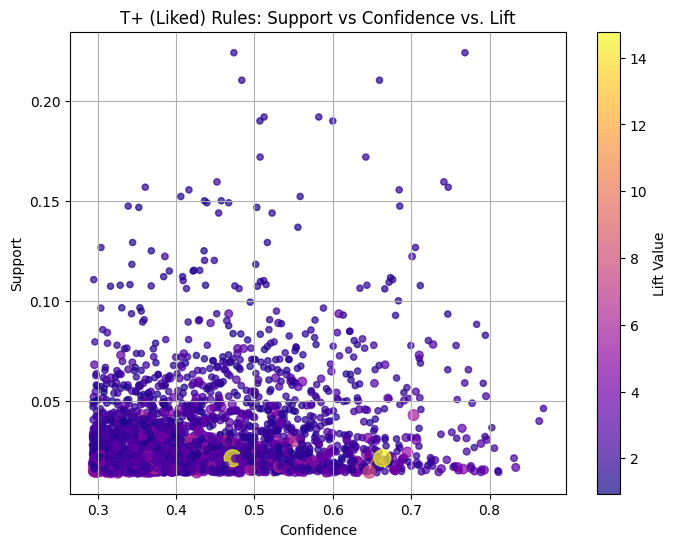

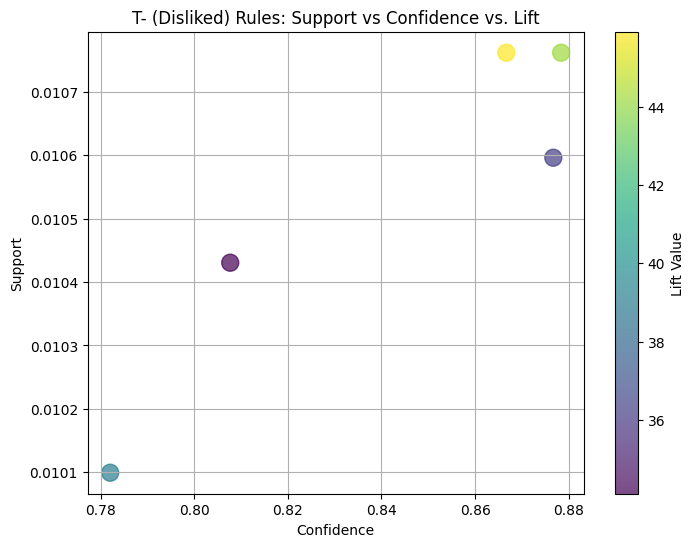

In [54]:


supports_plus = [r[2] for r in R_plus]
confidences_plus = [r[3] for r in R_plus]
lifts_plus = [r[4] for r in R_plus]
scaled_lifts_plus = np.clip(np.array(lifts_plus) * 10, 20, 150)

plt.figure(figsize=(8, 6))
scatter_plus = plt.scatter(confidences_plus, supports_plus, c=lifts_plus, s=scaled_lifts_plus, cmap='plasma', alpha=0.7)
plt.colorbar(scatter_plus).set_label('Lift Value')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.title("T+ (Liked) Rules: Support vs Confidence vs. Lift")
plt.grid(True)
plt.show()

supports_minus = [r[2] for r in R_minus]
confidences_minus = [r[3] for r in R_minus]
lifts_minus = [r[4] for r in R_minus]
scaled_lifts_minus = np.clip(np.array(lifts_minus) * 10, 20, 150)

plt.figure(figsize=(8, 6))
scatter_minus = plt.scatter(confidences_minus, supports_minus, c=lifts_minus, s=scaled_lifts_minus, cmap='viridis', alpha=0.7)
plt.colorbar(scatter_minus).set_label('Lift Value')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.title("T- (Disliked) Rules: Support vs Confidence vs. Lift")
plt.grid(True)
plt.show()

For liked rules: the results indicate that while most movie associations are modest, the algorithm successfully identifies several stronger patterns that could be useful for understanding user preferences or building recommendation systems.

For disliked rules: The rules have very low support (around 1%), meaning only a small fraction of users disliked these movie combinations, but they have high confidence (about 0.78–0.88), indicating that when one disliked movie appears, the related one is often disliked as well. The very high lift values (around 35–45) suggest strong negative preference patterns, meaning these movies are much more likely to be disliked together than expected by chance.

# Demographic Study

### Female and Male Comparison

In [38]:
females=users[users['Gender']=="F"]

In [39]:
females.head()

,Gender,Age,Occupation,Zip-code
UserID,,,,
1,F,1,10,48067
6,F,50,9,55117
10,F,35,1,95370
11,F,25,1,04093
16,F,35,0,20670


In [40]:
males=users[users['Gender']=="M"]

In [41]:
males.head()

,Gender,Age,Occupation,Zip-code
UserID,,,,
2,M,56,16,70072
3,M,25,15,55117
4,M,45,7,02460
5,M,25,20,55455
7,M,35,1,06810


In [91]:
from collections import defaultdict

T_females = defaultdict(list)
T_males= defaultdict(list)

In [92]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [93]:
users.head()

,Gender,Age,Occupation,Zip-code
UserID,,,,
1,F,1,10,48067
2,M,56,16,70072
3,M,25,15,55117
4,M,45,7,02460
5,M,25,20,55455


In [94]:
females_m=pd.merge(females,ratings,how='inner',on="UserID")

In [95]:
males_m=pd.merge(males,ratings,how='inner',on="UserID")

In [96]:
males_m.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Rating,Timestamp
0,2,M,56,16,70072,1357,5,978298709
1,2,M,56,16,70072,3068,4,978299000
2,2,M,56,16,70072,1537,4,978299620
3,2,M,56,16,70072,647,3,978299351
4,2,M,56,16,70072,2194,4,978299297


In [97]:
for user_id, rows in females_m.groupby("UserID"):
    for movie_id in rows["MovieID"]:
     T_females[user_id].append(str(movie_id))

In [98]:
for user_id, rows in males_m.groupby("UserID"):
    for movie_id in rows["MovieID"]:    
     T_males[user_id].append(str(movie_id))

In [79]:
transactions = preprocess_transactions(T_females)
sup_cache={}
transactions = filter_items_by_min_count(transactions, min_count=5)

In [80]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions,
    n_trials=10,
    max_k=5,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8),
    
)

In [81]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

[I 2026-03-09 21:54:02,947] A new study created in memory with name: no-name-c564572d-4aaf-406e-9b6b-dbeaae2b30f3
[I 2026-03-09 21:56:56,858] Trial 0 finished with value: 11.43915836155668 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 11.43915836155668.
[I 2026-03-09 21:56:58,336] Trial 1 finished with value: 15.80330636611899 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 1 with value: 15.80330636611899.
[I 2026-03-09 21:58:24,733] Trial 2 finished with value: 22.048785519437327 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 22.048785519437327.
[I 2026-03-09 21:59:00,039] Trial 3 finished with value: 12.496492001240886 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 22.048785519437327.
[I 2026-03-09 21:59:02,399] Trial 4 finished with value: 14.982583804912291 and parameters: 

Best Smin: 0.013832442448846112
Best Cmin: 0.2935967122017216
Best Score: 22.048785519437327
No. of rules: 2491
No. of itemsets: 5000


In [82]:
import pickle

result = {
    "params": params,
    "score": score,
    "rules": rules,
    "itemsets": itemset
}
with open("T_females_result.pkl", "wb") as f:
    pickle.dump(result, f)

In [83]:
with open("sup_cache_females.pkl", "wb") as f:
    pickle.dump(sup_cache, f)

In [115]:
import pickle
with open("T_females_result.pkl", "rb") as f:
    result = pickle.load(f)

T_females_rules = result["rules"]


In [102]:
import pickle
with open("sup_cache_females.pkl", "rb") as f:
    sup_cache_min = pickle.load(f)



In [105]:
Smin_T_min=result["params"]["Smin"]
Cmin_T_min=result["params"]["Cmin"]


In [100]:
transactions = preprocess_transactions(T_males)
transactions = filter_items_by_min_count(transactions, min_count=5)

In [107]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions,
    n_trials=10,
    max_k=5,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8),
    
)

In [108]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

[I 2026-03-09 22:05:31,520] A new study created in memory with name: no-name-ad88ec1d-5f16-49eb-b225-346e05badb35
[I 2026-03-09 22:20:53,066] Trial 0 finished with value: 10.002728901560324 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 10.002728901560324.
[I 2026-03-09 22:20:56,478] Trial 1 finished with value: 15.17376458457388 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 1 with value: 15.17376458457388.
[I 2026-03-09 22:26:09,740] Trial 2 finished with value: 21.480346547275808 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 21.480346547275808.
[I 2026-03-09 22:28:17,413] Trial 3 finished with value: 11.173936335631776 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 21.480346547275808.
[I 2026-03-09 22:28:19,044] Trial 4 finished with value: 14.343357049141746 and parameters

Best Smin: 0.013832442448846112
Best Cmin: 0.2935967122017216
Best Score: 21.480346547275808
No. of rules: 2601
No. of itemsets: 5000


In [109]:
import pickle

result = {
    "params": params,
    "score": score,
    "rules": rules,
    "itemsets": itemset
}
with open("T_males_result.pkl", "wb") as f:
    pickle.dump(result, f)

In [110]:
with open("sup_cache_males.pkl", "wb") as f:
    pickle.dump(sup_cache, f)

In [116]:
import pickle
with open("T_males_result.pkl", "rb") as f:
    result = pickle.load(f)

T_males_rules = result["rules"]


In [112]:
import pickle
with open("sup_cache_males.pkl", "rb") as f:
    sup_cache_min = pickle.load(f)



In [113]:
Smin_T_min=result["params"]["Smin"]
Cmin_T_min=result["params"]["Cmin"]


In [106]:
F_females = apriori(T_females, Smin_T_min,max_k=5,sup_cache=sup_cache_min)
R_females, sup_cache = generate_rules(F_minus, T_min, Cmin_T_min, sup_cache)

In [114]:
F_males = apriori(T_males, Smin_T_min,max_k=5,sup_cache=sup_cache_min)
R_males, sup_cache = generate_rules(F_males, T_males, Cmin_T_min, sup_cache)

In [118]:
F_females_named = [convert_itemset(it) for it in F_females]
F_males_named = [convert_itemset(it) for it in F_males]


In [119]:
R_females_named  = [convert_rule(r) for r in R_females]
R_males_named = [convert_rule(r) for r in R_males]

In [121]:
R_females_named[:2]

[(['Sex, Lies, and Videotape (1989)'],
  ['Rebel Without a Cause (1955)'],
  0.033352837916910474,
  0.32571428571428573,
  4.926068268015171),
 (['Rebel Without a Cause (1955)'],
  ['Sex, Lies, and Videotape (1989)'],
  0.033352837916910474,
  0.504424778761062,
  4.926068268015171)]

In [122]:
R_males_named[:2]

[(['Sex, Lies, and Videotape (1989)'],
  ['Rebel Without a Cause (1955)'],
  0.026783652736088664,
  0.2997416020671835,
  4.4919753583147815),
 (['Rebel Without a Cause (1955)'],
  ['Sex, Lies, and Videotape (1989)'],
  0.026783652736088664,
  0.40138408304498274,
  4.4919753583147815)]

In [123]:
print("\n--- Association Rules (Males) ---")
for i, rule in enumerate(R_males_named[:30]):
    antecedent, consequent, support, confidence, lift = rule
    print(f"{i+1}. Rule: {antecedent} -> {consequent}")
    print(f"    (Support: {support:.4f}, Confidence: {confidence:.4f}, Lift: {lift:.4f})")



--- Association Rules (Liked T+ and Disliked T-) ---
1. Rule: ['Sex, Lies, and Videotape (1989)'] -> ['Rebel Without a Cause (1955)']
    (Support: 0.0268, Confidence: 0.2997, Lift: 4.4920)
2. Rule: ['Rebel Without a Cause (1955)'] -> ['Sex, Lies, and Videotape (1989)']
    (Support: 0.0268, Confidence: 0.4014, Lift: 4.4920)
3. Rule: ['Hand That Rocks the Cradle, The (1992)'] -> ['No Way Out (1987)']
    (Support: 0.0192, Confidence: 0.3430, Lift: 5.2120)
4. Rule: ['Fletch (1985)'] -> ['Young Frankenstein (1974)']
    (Support: 0.0556, Confidence: 0.4990, Lift: 2.3388)
5. Rule: ['Entrapment (1999)'] -> ['Out of Sight (1998)']
    (Support: 0.0469, Confidence: 0.3333, Lift: 2.0135)
6. Rule: ['Grand Canyon (1991)'] -> ['Cider House Rules, The (1999)']
    (Support: 0.0203, Confidence: 0.3548, Lift: 3.1236)
7. Rule: ['Godzilla (Gojira) (1954)'] -> ['Crow, The (1994)']
    (Support: 0.0226, Confidence: 0.3740, Lift: 2.7457)
8. Rule: ['Rocky V (1990)'] -> ['Entrapment (1999)']
    (Support

In [124]:
print("\n--- Association Rules (Females) ---")
for i, rule in enumerate(R_females_named[:30]):
    antecedent, consequent, support, confidence, lift = rule
    print(f"{i+1}. Rule: {antecedent} -> {consequent}")
    print(f"    (Support: {support:.4f}, Confidence: {confidence:.4f}, Lift: {lift:.4f})")



--- Association Rules (Females) ---
1. Rule: ['Sex, Lies, and Videotape (1989)'] -> ['Rebel Without a Cause (1955)']
    (Support: 0.0334, Confidence: 0.3257, Lift: 4.9261)
2. Rule: ['Rebel Without a Cause (1955)'] -> ['Sex, Lies, and Videotape (1989)']
    (Support: 0.0334, Confidence: 0.5044, Lift: 4.9261)
3. Rule: ['No Way Out (1987)'] -> ['Hand That Rocks the Cradle, The (1992)']
    (Support: 0.0140, Confidence: 0.3429, Lift: 5.9790)
4. Rule: ['Fletch (1985)'] -> ['Young Frankenstein (1974)']
    (Support: 0.0345, Confidence: 0.5086, Lift: 3.2313)
5. Rule: ['Grand Canyon (1991)'] -> ['Cider House Rules, The (1999)']
    (Support: 0.0252, Confidence: 0.4388, Lift: 3.4241)
6. Rule: ['Superman (1978)'] -> ['Titanic (1997)']
    (Support: 0.0650, Confidence: 0.5286, Lift: 1.8360)
7. Rule: ['Dinosaur (2000)'] -> ['Prince of Egypt, The (1998)']
    (Support: 0.0158, Confidence: 0.3462, Lift: 4.0243)
8. Rule: ['Life Less Ordinary, A (1997)'] -> ['Good Will Hunting (1997)']
    (Support:

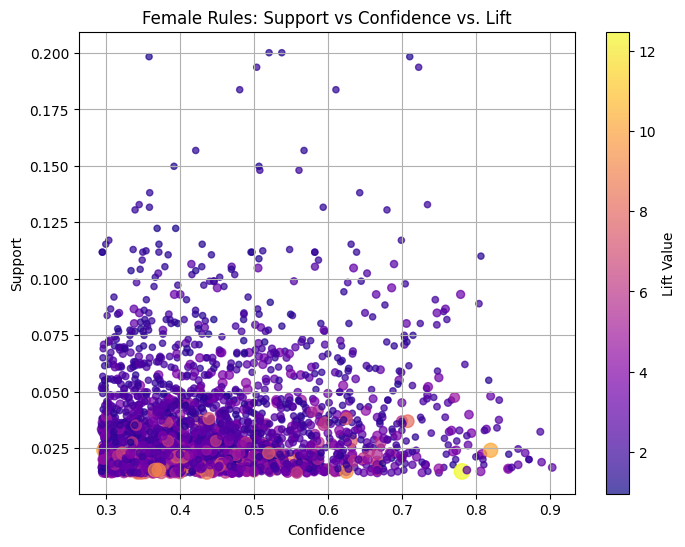

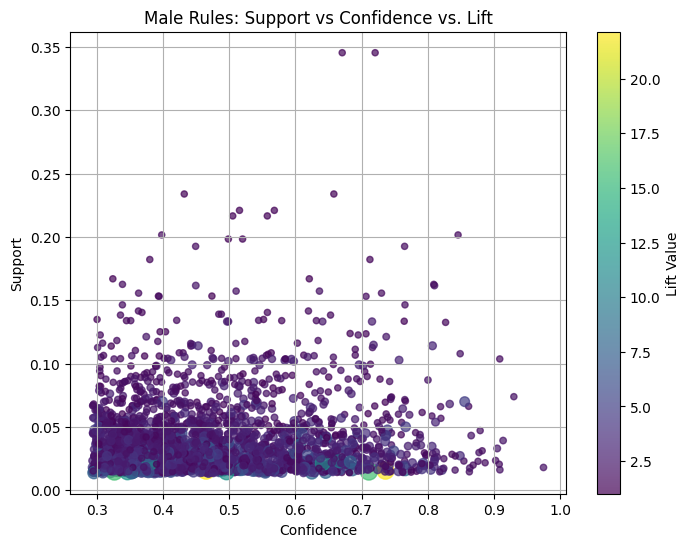

In [127]:


supports_females= [r[2] for r in R_females]
confidences_females = [r[3] for r in R_females]
lifts_females = [r[4] for r in R_females]
scaled_lifts_females = np.clip(np.array(lifts_females) * 10, 20, 150)

plt.figure(figsize=(8, 6))
scatter_female = plt.scatter(confidences_females, supports_females, c=lifts_females, s=scaled_lifts_females, cmap='plasma', alpha=0.7)
plt.colorbar(scatter_female).set_label('Lift Value')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.title("Female Rules: Support vs Confidence vs. Lift")
plt.grid(True)
plt.show()

supports_males = [r[2] for r in R_males]
confidences_males = [r[3] for r in R_males]
lifts_males = [r[4] for r in R_males]
scaled_lifts_males = np.clip(np.array(lifts_males) * 10, 20, 150)

plt.figure(figsize=(8, 6))
scatter_males = plt.scatter(confidences_males, supports_males, c=lifts_males, s=scaled_lifts_males, cmap='viridis', alpha=0.7)
plt.colorbar(scatter_males).set_label('Lift Value')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.title("Male Rules: Support vs Confidence vs. Lift")
plt.grid(True)
plt.show()

For female users, most rules are concentrated in a smaller region with moderate confidence (around 0.3–0.6) and relatively low support, and the lift values are generally moderate. This suggests more consistent and shared viewing patterns, where many users tend to watch similar combinations of movies. In contrast, the male user plot is more dispersed, with rules reaching higher confidence and lift values and a wider range of support. This indicates more diverse and stronger niche associations, meaning some movie combinations are particularly characteristic of specific male viewer groups. Overall, female viewing behavior appears more homogeneous, while male viewing behavior shows greater variability and stronger specialized preference patterns.

### Student and Non-student Comparison

In [196]:
students=users[users["Occupation"]==0]
nonStudents=users[users["Occupation"]!=0]

In [197]:
students_m=pd.merge(students,ratings,how='inner',on="UserID")
nonStudents_m=pd.merge(nonStudents,ratings,how='inner',on="UserID")

In [198]:
from collections import defaultdict

T_students = defaultdict(list)
T_nonStudents= defaultdict(list)

In [201]:
transactions_students = preprocess_transactions(T_students)
transactions_students = filter_items_by_min_count(transactions_students, min_count=5)

In [202]:
transactions_non = preprocess_transactions(T_nonStudents)
transactions_non = filter_items_by_min_count(transactions_non, min_count=5)

In [199]:
for user_id, rows in students_m.groupby("UserID"):
    for movie_id in rows["MovieID"]:
     T_students[user_id].append(str(movie_id))

In [200]:
for user_id, rows in nonStudents_m.groupby("UserID"):
    for movie_id in rows["MovieID"]:
     T_nonStudents[user_id].append(str(movie_id))

In [203]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions_students,
    n_trials=10,
    max_k=5,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8),
    
)

In [204]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

[I 2026-03-10 00:48:17,113] A new study created in memory with name: no-name-3b2db2fa-1826-432a-891e-d1ddfe0b2ce4
[I 2026-03-10 00:49:52,803] Trial 0 finished with value: 14.124252421809542 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 14.124252421809542.
[I 2026-03-10 00:49:54,295] Trial 1 finished with value: 17.605312132411925 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 1 with value: 17.605312132411925.
[I 2026-03-10 00:50:47,729] Trial 2 finished with value: 23.971034291144992 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 23.971034291144992.
[I 2026-03-10 00:51:11,913] Trial 3 finished with value: 15.975770430656661 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 23.971034291144992.
[I 2026-03-10 00:51:14,057] Trial 4 finished with value: 16.885528508625775 and paramete

Best Smin: 0.013832442448846112
Best Cmin: 0.2935967122017216
Best Score: 23.971034291144992
No. of rules: 2493
No. of itemsets: 5000


In [205]:
import pickle

result = {
    "params": params,
    "score": score,
    "rules": rules,
    "itemsets": itemset
}
with open("T_st_result.pkl", "wb") as f:
    pickle.dump(result, f)

In [206]:
with open("sup_cache_st.pkl", "wb") as f:
    pickle.dump(sup_cache, f)

In [207]:
import pickle
with open("T_st_result.pkl", "rb") as f:
    result = pickle.load(f)

T_min_rules = result["rules"]


In [208]:
import pickle
with open("sup_cache_st.pkl", "rb") as f:
    sup_cache_min = pickle.load(f)



In [211]:
F_st = apriori(T_students, Smin_T_st,max_k=5,sup_cache=sup_cache_min)
R_st, sup_cache = generate_rules(F_st, T_students, Cmin_T_st, sup_cache)

In [212]:
optimizer = OptimizationFactory.create(
    "bayesian",
    transactions_non,
    n_trials=10,
    max_k=5,
    max_itemsets=5000,
    max_rules=5000,
    seed=42,
    smin_range=(0.01, 0.08),
    cmin_range=(0.2, 0.8),
   
)

In [213]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

[I 2026-03-10 00:53:40,841] A new study created in memory with name: no-name-e288ba3f-c4f6-4e6b-93db-1ac0ee106de5
[I 2026-03-10 02:28:29,155] Trial 0 finished with value: 10.117240096784338 and parameters: {'Smin': 0.021789307659775742, 'Cmin': 0.7704285838459498}. Best is trial 0 with value: 10.117240096784338.
[I 2026-03-10 02:28:30,338] Trial 1 finished with value: 15.253068397361531 and parameters: {'Smin': 0.04582013868952863, 'Cmin': 0.559195090518222}. Best is trial 1 with value: 15.253068397361531.
[I 2026-03-10 02:42:00,244] Trial 2 finished with value: 21.141258007104003 and parameters: {'Smin': 0.013832442448846112, 'Cmin': 0.2935967122017216}. Best is trial 2 with value: 21.141258007104003.
[I 2026-03-10 02:55:29,362] Trial 3 finished with value: 11.42396184695922 and parameters: {'Smin': 0.011283783077201558, 'Cmin': 0.7197056874649612}. Best is trial 2 with value: 21.141258007104003.
[I 2026-03-10 02:55:35,086] Trial 4 finished with value: 14.370881558250796 and parameter

Best Smin: 0.013832442448846112
Best Cmin: 0.2935967122017216
Best Score: 21.141258007104003
No. of rules: 2564
No. of itemsets: 5000


In [214]:
import pickle

result_plus = {
    "params": params,
    "score": score,
    "rules": rules,
    "itemsets": itemset
}
with open("T_non_result.pkl", "wb") as f:
    pickle.dump(result_plus, f)

In [215]:
with open("sup_cache_non.pkl", "wb") as f:
    pickle.dump(sup_cache, f)

In [216]:
import pickle
with open("sup_cache_non.pkl", "rb") as f:
    sup_cache_non = pickle.load(f)


In [217]:
import pickle
with open("T_non_result.pkl", "rb") as f:
    result_non = pickle.load(f)

T_non_rules = result_plus["rules"]


# Genetic Algorithm Trial

In [271]:
transactions = preprocess_transactions(T_males)

transactions = filter_items_by_min_count(transactions, min_count=5)

In [272]:
optimizer = GeneticOptimization(
    transactions,
    pop_size=20,
    generations=30,
    patience=5,
    generation_time_limit=60
)

In [273]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

In [239]:
transactions = preprocess_transactions(T_females)

transactions = filter_items_by_min_count(transactions, min_count=5)

In [240]:
optimizer = GeneticOptimization(
    transactions,
    pop_size=20,
    generations=30,
    patience=5,
    generation_time_limit=60
)

In [241]:
params, score, rules, itemsets, sup_cache = optimizer.optimize()

print("Best Smin:", params["Smin"])
print("Best Cmin:", params["Cmin"])
print("Best Score:", score)
print("No. of rules:", len(rules))
print("No. of itemsets:", len(itemsets))

Gen 01 | best fitness=16.899507 | global best=16.899507 | no_improve=0/5
Gen 02 | best fitness=16.899507 | global best=16.899507 | no_improve=1/5
Stopping evaluation in generation 02: time limit of 60.0s exceeded.
Gen 03 | best fitness=17.412850 | global best=17.412850 | no_improve=0/5
Gen 04 | best fitness=17.412850 | global best=17.412850 | no_improve=1/5
Gen 05 | best fitness=17.827470 | global best=17.827470 | no_improve=0/5
Gen 06 | best fitness=17.827470 | global best=17.827470 | no_improve=1/5
Gen 07 | best fitness=17.989891 | global best=17.989891 | no_improve=0/5
Stopping evaluation in generation 07: time limit of 60.0s exceeded.
Gen 08 | best fitness=17.989891 | global best=17.989891 | no_improve=1/5
Stopping evaluation in generation 08: time limit of 60.0s exceeded.
Gen 09 | best fitness=17.989891 | global best=17.989891 | no_improve=2/5
Stopping evaluation in generation 09: time limit of 60.0s exceeded.
Gen 10 | best fitness=17.989891 | global best=17.989891 | no_improve=3/

In [270]:
result_gen_females

{'params': {'Smin': 0.05, 'Cmin': 0.33574831926926374},
 'score': 17.98989066517856,
 'rules': [(frozenset({'1200'}),
   frozenset({'648'}),
   0.15100438697760332,
   0.4268929503916449,
   1.5292583690208552),
  (frozenset({'648'}),
   frozenset({'1200'}),
   0.15100438697760332,
   0.5409429280397022,
   1.5292583690208552),
  (frozenset({'2371'}),
   frozenset({'1278'}),
   0.055645347494804896,
   0.49896480331262943,
   2.338762514228353),
  (frozenset({'3863'}),
   frozenset({'3623'}),
   0.06095589933040868,
   0.5038167938931297,
   2.0624107129973015),
  (frozenset({'1721'}),
   frozenset({'2640'}),
   0.08912491341491573,
   0.36622390891840606,
   1.5673080528909256),
  (frozenset({'2640'}),
   frozenset({'1721'}),
   0.08912491341491573,
   0.3814229249011858,
   1.5673080528909256),
  (frozenset({'2395'}),
   frozenset({'1198'}),
   0.12329716000923574,
   0.5680851063829787,
   1.2669292460065298),
  (frozenset({'474'}),
   frozenset({'2699'}),
   0.08773955206649735,
  

In [260]:
F_males = apriori(T_females, Smin_T_gen_females,max_k=5,sup_cache=sup_cache_gen_females)
R_males, sup_cache = generate_rules(F_females, T_females, Cmin_T_gen_females, sup_cache_gen_females)

In [244]:
F_females_named = [convert_itemset(it) for it in F_females]
F_males_named = [convert_itemset(it) for it in F_males]


In [245]:
R_females_named  = [convert_rule(r) for r in R_females]
R_males_named = [convert_rule(r) for r in R_males]

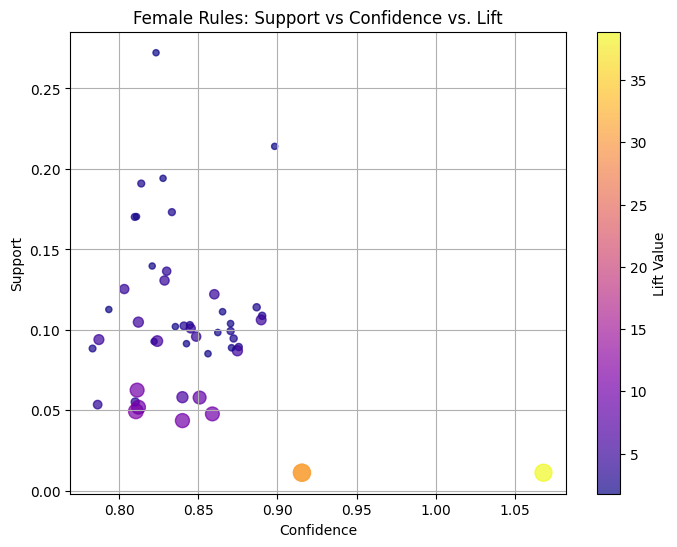

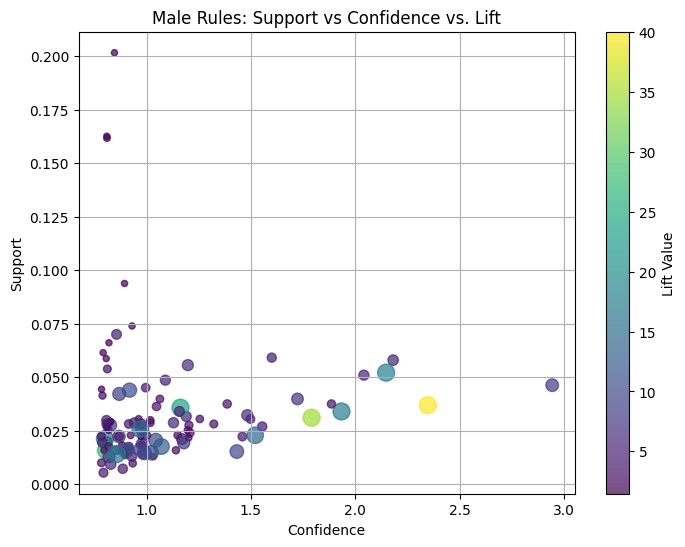

In [246]:


supports_females= [r[2] for r in R_females]
confidences_females = [r[3] for r in R_females]
lifts_females = [r[4] for r in R_females]
scaled_lifts_females = np.clip(np.array(lifts_females) * 10, 20, 150)

plt.figure(figsize=(8, 6))
scatter_female = plt.scatter(confidences_females, supports_females, c=lifts_females, s=scaled_lifts_females, cmap='plasma', alpha=0.7)
plt.colorbar(scatter_female).set_label('Lift Value')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.title("Female Rules: Support vs Confidence vs. Lift")
plt.grid(True)
plt.show()

supports_males = [r[2] for r in R_males]
confidences_males = [r[3] for r in R_males]
lifts_males = [r[4] for r in R_males]
scaled_lifts_males = np.clip(np.array(lifts_males) * 10, 20, 150)

plt.figure(figsize=(8, 6))
scatter_males = plt.scatter(confidences_males, supports_males, c=lifts_males, s=scaled_lifts_males, cmap='viridis', alpha=0.7)
plt.colorbar(scatter_males).set_label('Lift Value')
plt.xlabel("Confidence")
plt.ylabel("Support")
plt.title("Male Rules: Support vs Confidence vs. Lift")
plt.grid(True)
plt.show()